### 5.1. Подготовка среды

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import matplotlib.dates as mdates

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 5)

### 5.2. Загрузка данных

In [3]:
wti = pd.read_csv("wti-daily.csv")
brent = pd.read_csv("brent-daily.csv")

display(wti.head())
display(brent.head())

,Date,Price
0,1986-01-02,25.56
1,1986-01-03,26.00
2,1986-01-06,26.53
3,1986-01-07,25.85
4,1986-01-08,25.87


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [4]:
wti.info()
print ("="*30)
brent.info()

<class 'pandas.DataFrame'>
RangeIndex: 10148 entries, 0 to 10147
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    10148 non-null  str    
 1   Price   10148 non-null  float64
dtypes: float64(1), str(1)
memory usage: 158.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9879 non-null   str    
 1   Price   9879 non-null   float64
dtypes: float64(1), str(1)
memory usage: 154.5 KB


In [5]:
# Это база
display(wti.describe())
display(brent.describe())

,Price
count,10148.000000
mean,48.287490
std,29.482496
min,-36.980000
25%,20.330000
50%,42.955000
75%,71.280000
max,145.310000


,Price
count,9879.000000
mean,51.073789
std,32.683857
min,9.100000
25%,19.530000
50%,46.010000
75%,74.690000
max,143.950000


In [6]:
# А это пусто
wti.isna().sum()

Date     0
Price    0
dtype: int64

In [7]:
# И это пусто
brent.isna().sum()

Date     0
Price    0
dtype: int64

### 5.3. Подготовка и очистка данных

In [8]:
# "Date" явно переводим к типу даты/времени
wti["Date"] = pd.to_datetime(wti["Date"])
brent["Date"] = pd.to_datetime(brent["Date"])


# Меняем цену на техас и брент, делаем дату индексом, сортируем
wti = wti.rename(columns={"Price": "WTI"}).set_index("Date").sort_index()
brent = brent.rename(columns={"Price": "Brent"}).set_index("Date").sort_index()

# Нахренато заменяем пропуски интерполяцией (isna().sum() == 0)
wti["WTI"] = wti["WTI"].interpolate()
brent["Brent"] = brent["Brent"].interpolate()

# Объединяем фреймы
df = wti.join(brent, how="inner")
display(df.head())

,WTI,Brent
Date,,
1987-05-20,19.75,18.63
1987-05-21,19.95,18.45
1987-05-22,19.68,18.55
1987-05-26,19.35,18.63
1987-05-27,19.38,18.60


## Поясняем
* Дату переводим в datetime, чтобы работали временные операции Pandas (resample, сдвиги, окна, фильтрация по датам) корректно работает только с типом datetime64.
* Дата в индексе делает ряд «по времени по оси X» и упрощает объединение WTI и Brent по датам.
* Сортировка по индексу гарантирует строгий хронологический порядок, без него дифференциалы и доходности теряют смысл.
* Пропуски нельзя просто игнорировать: они искажают доходности и волатильность, создавая «дыры» во времени.
* Линейная интерполяция — базовый способ аккуратно заполнить редкие пропуски в ценовом ряду, сохранив общую форму динамики.

In [9]:
# абсолютное изменение цены
df["WTI_diff"] = df["WTI"].diff()

# дневная доходность
df["WTI_ret"] = df["WTI"].pct_change()

# скользящее среднее (7 дней)
df["WTI_rolling_mean_7"] = df["WTI"].rolling(7).mean()

# скользящая волатильность (стд дневной доходности за 30 дней)
df["WTI_volatility_30"] = df["WTI_ret"].rolling(30).std()

# лаговые признаки
df["WTI_lag_1"] = df["WTI"].shift(1)
df["WTI_lag_7"] = df["WTI"].shift(7)

# базовые признаки для Brent
df["Brent_diff"] = df["Brent"].diff()
df["Brent_ret"] = df["Brent"].pct_change()

In [10]:
df[["WTI", "WTI_diff", "WTI_ret", "WTI_rolling_mean_7",
    "WTI_volatility_30", "WTI_lag_1", "WTI_lag_7"]].head()

,WTI,WTI_diff,WTI_ret,WTI_rolling_mean_7,WTI_volatility_30,WTI_lag_1,WTI_lag_7
Date,,,,,,,
1987-05-20,19.75,NaN,NaN,NaN,NaN,NaN,NaN
1987-05-21,19.95,0.20,0.010127,NaN,NaN,19.75,NaN
1987-05-22,19.68,-0.27,-0.013534,NaN,NaN,19.95,NaN
1987-05-26,19.35,-0.33,-0.016768,NaN,NaN,19.68,NaN
1987-05-27,19.38,0.03,0.001550,NaN,NaN,19.35,NaN


## Бригада поясняет:
* WTI_diff отражает абсолютное дневное изменение цены, что позволяет видеть масштабы скачков в долларном выражении.
* WTI_ret - относительное изменение (дневная доходность), удобная величина для сравнения разных периодов и сопоставления с рядом Brent.
* WTI_rolling_mean_7 сглаживает краткосрочные колебания и показывает локальный уровень цен за неделю, а WTI_volatility_30 измеряет нестабильность доходностей на 30‑дневном окне.
* Лаги WTI_lag_1 и WTI_lag_7 фиксируют значения цены в прошлом и нужны для анализа зависимости текущего уровня от предыдущих дней, а также как потенциальные признаки в моделях прогнозирования.



### 5.4. Первичный анализ данных

In [11]:
# первичный описательный анализ объединённого датафрейма
display(df[["WTI", "Brent"]].describe())

print("Минимальные значения:")
print(df[["WTI", "Brent"]].min())

print("\nМаксимальные значения:")
print(df[["WTI", "Brent"]].max())

print("\nПериод наблюдений:")
print("с", df.index.min(), "по", df.index.max())

print("\nКоличество наблюдений:", len(df))

,WTI,Brent
count,9704.000000,9704.000000
mean,49.455938,51.137665
std,29.324569,32.778523
min,-36.980000,9.100000
25%,20.957500,19.500000
50%,45.720000,46.010000
75%,71.960000,74.782500
max,145.310000,143.950000


Минимальные значения:
WTI     -36.98
Brent     9.10
dtype: float64

Максимальные значения:
WTI      145.31
Brent    143.95
dtype: float64

Период наблюдений:
с 1987-05-20 00:00:00 по 2026-04-27 00:00:00

Количество наблюдений: 9704


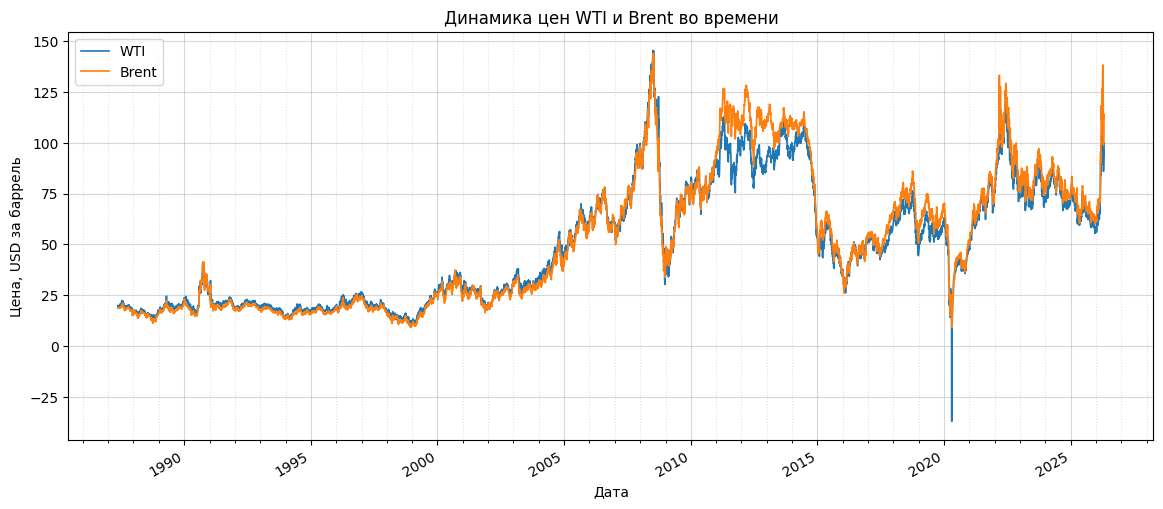

In [12]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["WTI"], label="WTI", linewidth=1.2)
ax.plot(df.index, df["Brent"], label="Brent", linewidth=1.2)

ax.set_title("Динамика цен WTI и Brent во времени")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, USD за баррель")

# major ticks: каждые 5 лет, с подписями
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# minor ticks: каждый год, без подписей
ax.xaxis.set_minor_locator(mdates.YearLocator(1))

# сетка
ax.grid(True, which="major", linestyle="-", alpha=0.5)
ax.grid(True, which="minor", linestyle=":", alpha=0.35)

ax.legend()
fig.autofmt_xdate()
plt.show()

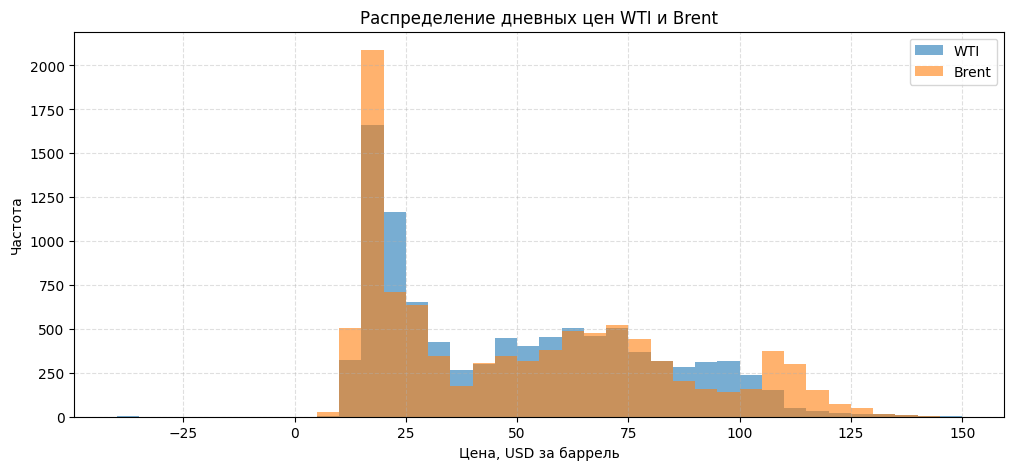

In [13]:
bins = range(-40, 155, 5)

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df["WTI"].dropna(), bins=bins, alpha=0.6, label="WTI")
ax.hist(df["Brent"].dropna(), bins=bins, alpha=0.6, label="Brent")

ax.set_title("Распределение дневных цен WTI и Brent")
ax.set_xlabel("Цена, USD за баррель")
ax.set_ylabel("Частота")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.show()

По графикам видно, что WTI и Brent ведут себя очень похоже: ряды практически совпадают по форме, крупные всплески и падения приходятся на одни и те же периоды (2008–2009 гг., 2014–2016 гг., 2020 г. и недавние всплески после 2022 г.). На гистограмме основная масса наблюдений для обоих эталонов сосредоточена примерно в диапазоне 20–80 долларов за баррель (высоченный пик 20–25 означает, что особенно много дней цена была именно в этом узком коридоре, это отражает длительный ранний период истории, когда нефть торговалась относительно дёшево и стабильно), при этом у Brent распределение слегка сдвинуто вправо, что отражает его более высокий средний уровень цен по сравнению с WTI. В правом хвосте гистограммы видны редкие, но существенные эпизоды очень высоких цен (выше 100–120 долларов), а в левом хвосте для WTI выделяется аномальный участок с отрицательными значениями, соответствующий кратковременному обвалу цен в период COVID‑кризиса.

### 5.5. Инженерные признаки

In [14]:
# абсолютное изменение цены
df["WTI_diff"] = df["WTI"].diff()

# дневная доходность
df["WTI_ret"] = df["WTI"].pct_change()

# скользящее среднее (7 дней)
df["WTI_rolling_mean_7"] = df["WTI"].rolling(7).mean()

# скользящая волатильность (стд дневной доходности за 30 дней)
df["WTI_volatility_30"] = df["WTI_ret"].rolling(30).std()

# лаговые признаки
df["WTI_lag_1"] = df["WTI"].shift(1)
df["WTI_lag_7"] = df["WTI"].shift(7)

# базовые признаки для Brent
df["Brent_diff"] = df["Brent"].diff()
df["Brent_ret"] = df["Brent"].pct_change()

In [15]:
# пример: смотрим данные за пару недель
sample = df.loc["2005-01-10":"2005-01-25", 
                ["WTI", "WTI_diff", "WTI_ret", 
                 "WTI_rolling_mean_7", "WTI_volatility_30",
                 "WTI_lag_1", "WTI_lag_7",
                 "Brent", "Brent_diff", "Brent_ret"]]

display(sample)

,WTI,WTI_diff,WTI_ret,WTI_rolling_mean_7,WTI_volatility_30,WTI_lag_1,WTI_lag_7,Brent,Brent_diff,Brent_ret
Date,,,,,,,,,,
2005-01-10,45.31,-0.01,-0.000221,44.365714,0.030258,45.32,41.78,44.71,1.43,0.033041
2005-01-11,45.66,0.35,0.007725,44.647143,0.030281,45.31,43.69,43.45,-1.26,-0.028182
2005-01-12,46.46,0.80,0.017521,45.090000,0.030433,45.66,43.36,43.75,0.30,0.006904
2005-01-13,48.11,1.65,0.035514,45.682857,0.031092,46.46,43.96,45.76,2.01,0.045943
2005-01-14,48.41,0.30,0.006236,46.397143,0.031052,48.11,43.41,45.26,-0.50,-0.010927
2005-01-18,48.46,0.05,0.001033,46.818571,0.027807,48.41,45.51,45.18,-0.08,-0.001768
2005-01-19,47.61,-0.85,-0.017540,47.145714,0.026329,48.46,45.32,45.16,-0.02,-0.000443
2005-01-20,47.01,-0.60,-0.012602,47.388571,0.026215,47.61,45.31,44.06,-1.10,-0.024358
2005-01-21,48.31,1.30,0.027654,47.767143,0.026562,47.01,45.66,45.88,1.82,0.041307


#### Очень короткое объяснение по каждой группе 
* WTI_diff — абсолютное дневное изменение цены: показывает, на сколько долларов за день выросла или упала нефть, удобно для оценки масштаба движений.
* WTI_ret — относительное изменение (pct_change), то есть дневная доходность в долях; этот признак нормирует изменения и позволяет сравнивать периоды и сопоставлять WTI с Brent по процентам, а не по долларам.
* Скользящее среднее WTI_rolling_mean_7 сглаживает краткосрочный шум и отражает локальный уровень цен за неделю, а WTI_volatility_30 — стандартное отклонение дневных доходностей на окне 30 дней, которое используется как простая мера текущей волатильности рынка.
* Лаги WTI_lag_1 и WTI_lag_7 сохраняют значения цены 1 и 7 дней назад; они нужны для анализа зависимости текущей цены от прошлых уровней и для возможных простых моделей, основанных на прошлых значениях ряда. Аналогичные признаки Brent_diff и Brent_ret строятся для Brent, чтобы затем напрямую сравнивать изменения и доходности двух эталонов.



### 5.6. NumPy-вычисления

In [16]:
# перевод ряда WTI в NumPy-массив
arr = df["WTI"].dropna().to_numpy()

# среднее значение;
mean_val = np.mean(arr)

# стандартное отклонение
std_val = np.std(arr)

# медиана;
median_val = np.median(arr)

# квантили;
q25 = np.quantile(arr, 0.25)
q75 = np.quantile(arr, 0.75)

# градиент;
grad = np.gradient(arr)

print("mean   =", mean_val)
print("std    =", std_val)
print("median =", median_val)
print("q25    =", q25)
print("q75    =", q75)

mean   = 49.455937757625726
std    = 29.323057643600368
median = 45.72
q25    = 20.9575
q75    = 71.96


In [17]:
# простая линейная аппроксимация тренда WTI на всём периоде
x = np.arange(len(arr))           # условная ось времени: 0, 1, 2, ...
slope, intercept = np.polyfit(x, arr, 1)

print("slope      =", slope)
print("intercept  =", intercept)

slope      = 0.007531603969614352
intercept  = 12.916361099041698


Пояснительная бригада переводит ряд цен WTI в обычный NumPy‑массив и считает по нему несколько простых чисел. Среднее и медиана показывают, вокруг каких уровней в целом крутились цены, а стандартное отклонение и квартили — насколько сильно они разъезжались вверх‑вниз. Градиент даёт представление о том, насколько быстро менялась цена от дня к дню: большие по модулю значения соответствуют дням с самыми резкими движениями.

### 5.7. Анализ временного ряда

In [18]:
# 5.7.1 Построить **скользящее среднее**.
# уже посчитали в 5.5 df["WTI_rolling_mean_7"] = df["WTI"].rolling(7).mean()

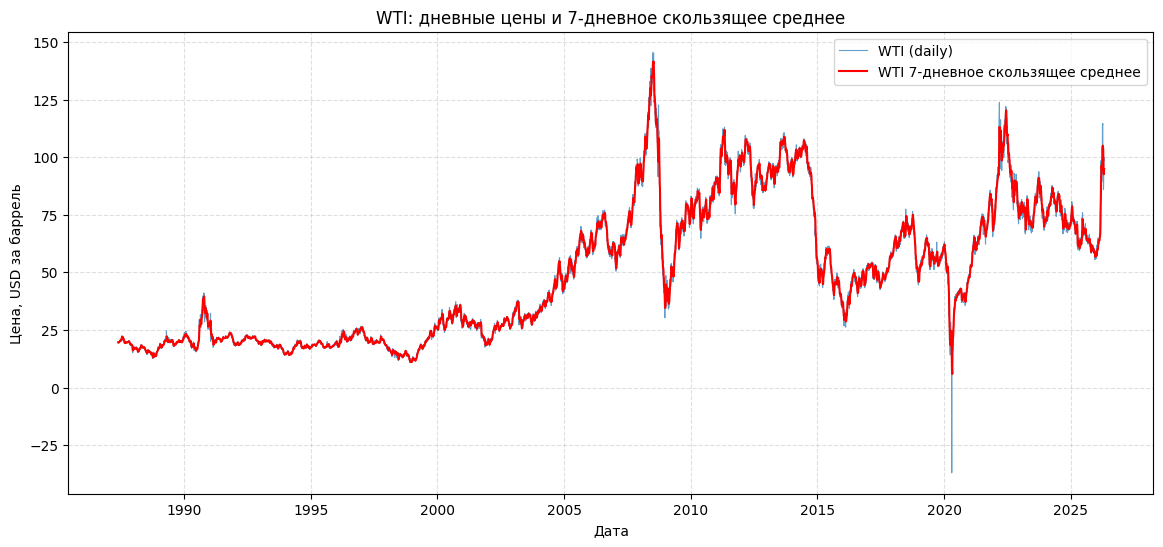

In [19]:
# 5.7.1 График дневных цен и скользящего среднего

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["WTI"], label="WTI (daily)", linewidth=0.8, alpha=0.7)
ax.plot(df.index, df["WTI_rolling_mean_7"], 
        label="WTI 7-дневное скользящее среднее", linewidth=1.5, color="red")

ax.set_title("WTI: дневные цены и 7-дневное скользящее среднее")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, USD за баррель")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

In [20]:
# 5.7.2 ыполнить **ресемплинг по месяцам**.
# месячные средние цен WTI и Brent
monthly = df[["WTI", "Brent"]].resample("ME").mean()

display(monthly.head())

,WTI,Brent
Date,,
1987-05-31,19.535714,18.577143
1987-06-30,20.073333,18.860476
1987-07-31,21.342174,19.856522
1987-08-31,20.310952,18.979524
1987-09-30,19.530000,18.313182


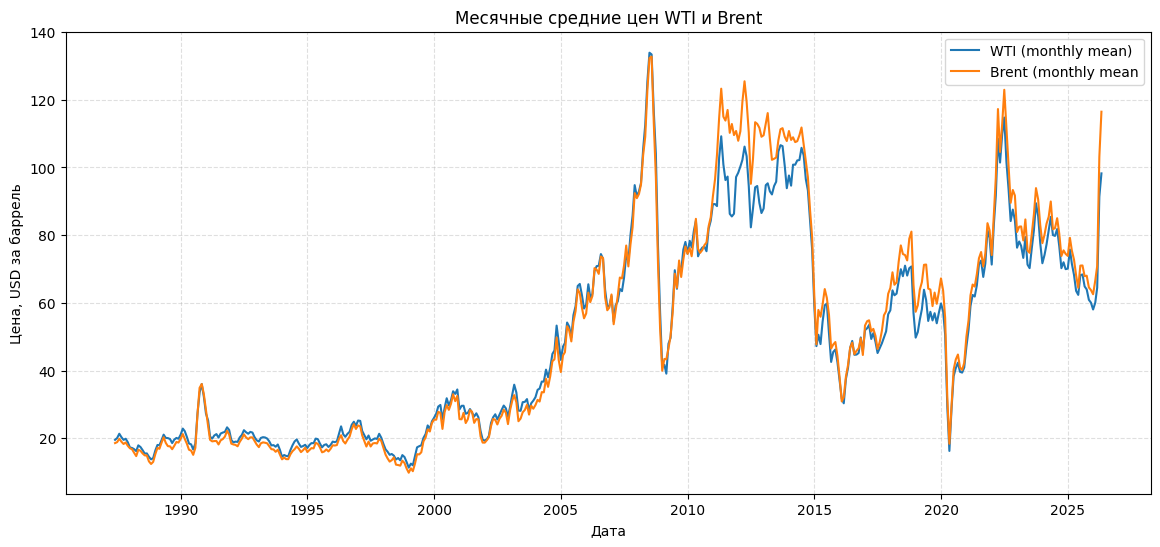

In [21]:
# 5.7.2 график месячных средних

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly.index, monthly["WTI"], label="WTI (monthly mean)")
ax.plot(monthly.index, monthly["Brent"], label="Brent (monthly mean")

ax.set_title("Месячные средние цен WTI и Brent")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, USD за баррель")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

5.7.3. Исследовать **изменения цены во времени**.
Этому служат сразу два уровня:
*дневной график WTI + скользящее среднее (5.7.1) — видно, когда цена растёт, падает, стоит на месте, а также как быстро происходят эти изменения;
*график месячных средних WTI и Brent (5.7.2) — показывает крупные циклы: периоды дешёвой нефти, подъёмы до 100+, падения в кризисы.
Краткий смысл: на дневном графике видны локальные движения и шум, на месячном — большие волны и режимы рынка (рост, плато, спад).

5.7.4. Оценить **волатильность**.
Признак волатильности мы посчитали в 5.5:

df["WTI_volatility_30"] = df["WTI_ret"].rolling(30).std().

Это стандартное отклонение дневных доходностей на окне в 30 дней — простая скользящая оценка текущей «раздерганности» рынка.

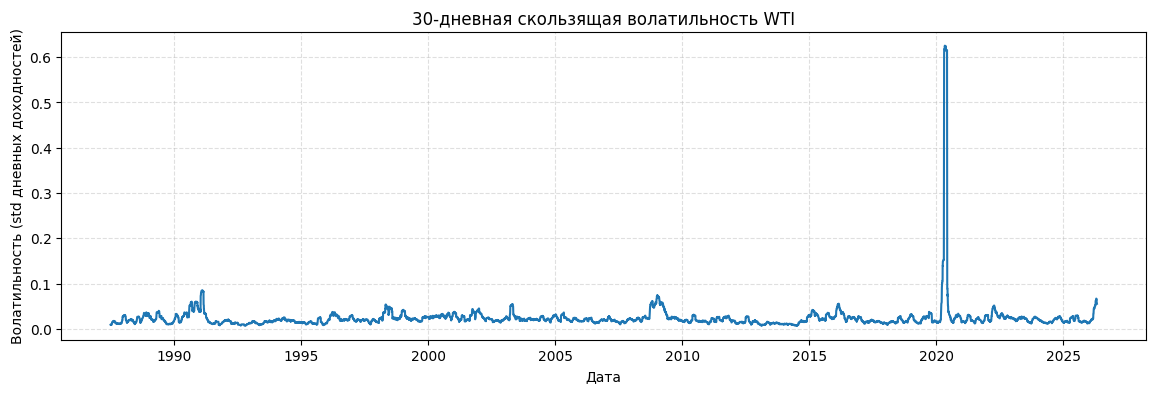

In [22]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["WTI_volatility_30"])
ax.set_title("30-дневная скользящая волатильность WTI")
ax.set_xlabel("Дата")
ax.set_ylabel("Волатильность (std дневных доходностей)")
ax.grid(True, linestyle="--", alpha=0.4)
plt.show()

 По этому графику видно, в какие моменты волатильность «взрывается» (кризисы) и где она низкая (спокойные периоды).

5.7.5. Сделать вывод, где ряд выглядит стабильным, а где — нет.
По графику цен и 7‑дневного скользящего среднего WTI видно, что до начала 2000‑х ряд ведёт себя относительно стабильно: колебания невелики, скользящее среднее движется плавно, без резких наклонов. Начиная с середины 2000‑х появляются участки сильных трендов и больших колебаний, особенно вокруг кризиса 2008–2009 гг., падения цен в 2014–2016 гг. и эпизода 2020 г.; на эти же периоды приходится всплеск 30‑дневной волатильности, что указывает на высокую нестабильность ряда. Между крупными кризисами, когда волатильность снижается и скользящее среднее идёт почти горизонтально, можно говорить о более спокойных режимах рынка.
**Аномальный провал WTI весной 2020 года связан с пандемией COVID‑19: резким падением спроса, переполнением хранилищ и тем, что фьючерсы WTI в апреле 2020 впервые в истории ушли в отрицательные значения.**

#### Дополнительно для магистерского уровня

In [23]:
def rolling_slope(series, window=30):
    slopes = [np.nan] * len(series)
    y = series.to_numpy()

    for i in range(window - 1, len(series)):
        y_window = y[i - window + 1:i + 1]
        x_window = np.arange(window)

        if np.isnan(y_window).any():
            continue

        slope = np.polyfit(x_window, y_window, 1)[0]
        slopes[i] = slope

    return pd.Series(slopes, index=series.index)

# локальный тренд WTI на окне 30 дней
df["WTI_trend_30"] = rolling_slope(df["WTI"], window=30)

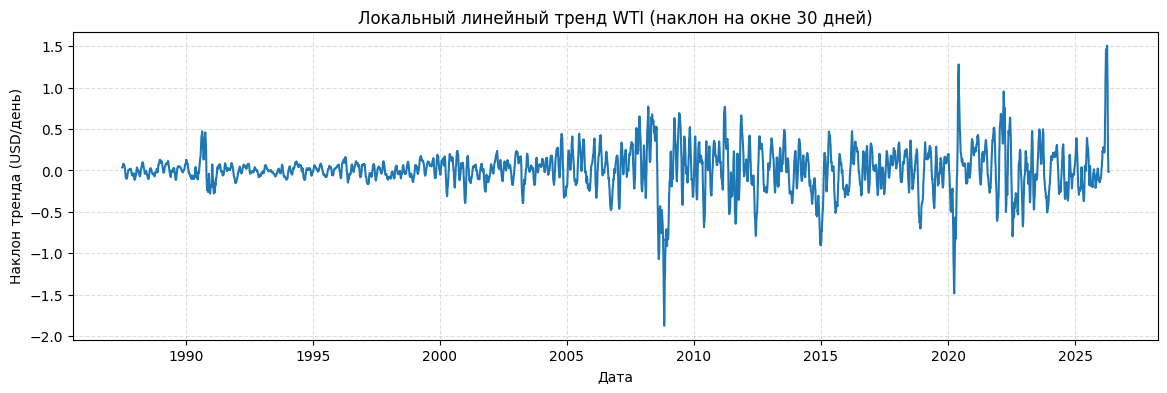

In [24]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["WTI_trend_30"])
ax.set_title("Локальный линейный тренд WTI (наклон на окне 30 дней)")
ax.set_xlabel("Дата")
ax.set_ylabel("Наклон тренда (USD/день)")
ax.grid(True, linestyle="--", alpha=0.4)
plt.show()

Чтобы не смотреть на цены «на глазок», я посчитал локальный тренд WTI на окне 30 дней. Для каждого дня беру последние 30 значений, через них провожу прямую (np.polyfit) и забираю её наклон в признак WTI_trend_30. Если наклон положительный — на этом участке рынок скорее ползёт вверх, если отрицательный — тенденция вниз, если около нуля — болтаемся в боковике. По сути это способ честно ответить на вопрос «мы сейчас растём или мне просто кажется, потому что последние пару дней повезло?».

### 5.8. Сравнение WTI и Brent

In [25]:
# 5.8.1 Сравнить уровни цен WTI и Brent
df[["WTI", "Brent"]].describe()

,WTI,Brent
count,9704.000000,9704.000000
mean,49.455938,51.137665
std,29.324569,32.778523
min,-36.980000,9.100000
25%,20.957500,19.500000
50%,45.720000,46.010000
75%,71.960000,74.782500
max,145.310000,143.950000


In [26]:
# 5.8.2 Посчитать корреляцию между ценами
price_corr = df["WTI"].corr(df["Brent"])

price_corr

np.float64(0.9910584364652559)

In [27]:
# 5.8.3 Посчитать корреляцию между дневными доходностями
ret_corr = df["WTI_ret"].corr(df["Brent_ret"])

ret_corr

np.float64(0.4789630203458596)

### 5.8.4 Вывод
В целом ряды WTI и Brent очень похожи: они проходят через одни и те же крупные пики и провалы, а Brent почти всегда чуть дороже, что видно и по средним уровням, и по графикам. Уровень корреляции цен 0.99 — эталоны живут в одном «ценовом мире», различаясь в основном постоянной надбавкой Brent к WTI. Корреляция дневных доходностей тоже высокая, то есть большинство шоков рынок отыгрывает синхронно, однако она ниже, чем корреляция уровней, поэтому краткосрочно возможны расхождения и игра на спреде между эталонами.

По описательным статистикам видно, что Brent в среднем дороже WTI: его средний уровень и медиана немного выше, чем у WTI. Минимумы и максимумы у рядов сопоставимы по порядку величины, но Brent чаще проводит время на более высоких ценовых уровнях, что соответствует его исторической премии к WTI: за международный эталон обычно платят немного дороже.

### 5.9. Поиск кризисных периодов

#### Нужно сделать:

1. найти все кризисные дни;
2. вывести их количество;
3. показать несколько примеров дат;
4. отметить эти точки на графике;
5. объяснить, почему такой критерий разумен для первичного анализа.

Ввожу простой критерий «плохого дня»: если дневная доходность WTI меньше −8%, помечаю этот день как кризисный. Это довольно жёсткий порог, то есть в выборку попадают только действительно сильные обвалы, а не обычный рыночный шум.

In [28]:
#  5.9.1 Критерий и флаг кризисного дня

threshold = -0.08
df["WTI_crisis"] = df["WTI_ret"] < threshold
df["WTI_crisis"]

Date
1987-05-20    False
1987-05-21    False
1987-05-22    False
1987-05-26    False
1987-05-27    False
              ...  
2026-04-21    False
2026-04-22    False
2026-04-23    False
2026-04-24    False
2026-04-27    False
Name: WTI_crisis, Length: 9704, dtype: bool

In [29]:
# 5.9.2 Найти все кризисные дни и их количество
wti_crisis_days = df[df["WTI_crisis"]]

print("Количество кризисных дней WTI:", len(wti_crisis_days))
wti_crisis_days.head()

Количество кризисных дней WTI: 66


,WTI,Brent,WTI_diff,WTI_ret,WTI_rolling_mean_7,WTI_volatility_30,WTI_lag_1,WTI_lag_7,Brent_diff,Brent_ret,WTI_trend_30,WTI_crisis
Date,,,,,,,,,,,,
1988-10-24,12.94,12.20,-1.28,-0.090014,14.517143,0.034853,14.22,14.26,-1.28,-0.094955,-0.026796,True
1989-04-24,20.64,21.20,-2.74,-0.117194,22.135714,0.036108,23.38,20.26,-0.40,-0.018519,0.102325,True
1989-05-24,19.68,18.15,-2.09,-0.096004,20.561429,0.039958,21.77,20.53,0.45,0.025424,-0.052060,True
1990-08-08,26.19,25.15,-3.41,-0.115203,24.882857,0.051204,29.60,20.24,-2.20,-0.080439,0.338543,True
1990-08-27,27.36,27.65,-3.74,-0.120257,29.484286,0.057620,31.10,27.40,-4.00,-0.126382,0.455141,True


In [30]:
# Сами даты

wti_crisis_days.index

DatetimeIndex(['1988-10-24', '1989-04-24', '1989-05-24', '1990-08-08',
               '1990-08-27', '1990-10-17', '1990-10-19', '1990-10-22',
               '1990-11-30', '1991-01-17', '1991-01-28', '1991-02-21',
               '1995-08-29', '1996-04-26', '1998-04-23', '1998-05-19',
               '1998-11-24', '1998-12-17', '2000-01-26', '2000-06-26',
               '2000-09-21', '2000-12-20', '2001-09-24', '2001-11-14',
               '2001-11-15', '2003-03-18', '2003-03-26', '2003-06-26',
               '2005-03-23', '2008-09-23', '2008-09-29', '2008-10-10',
               '2008-11-20', '2008-12-01', '2008-12-17', '2008-12-18',
               '2008-12-19', '2009-01-07', '2009-01-27', '2009-03-02',
               '2009-04-20', '2011-05-05', '2014-11-28', '2015-02-04',
               '2019-08-01', '2020-03-06', '2020-03-09', '2020-03-16',
               '2020-03-18', '2020-03-20', '2020-03-24', '2020-03-26',
               '2020-03-30', '2020-04-07', '2020-04-09', '2020-04-14',
      

In [31]:
# 5.9.3 Показать несколько примеров дат

wti_crisis_days[["WTI", "WTI_ret"]].head(10)

,WTI,WTI_ret
Date,,
1988-10-24,12.94,-0.090014
1989-04-24,20.64,-0.117194
1989-05-24,19.68,-0.096004
1990-08-08,26.19,-0.115203
1990-08-27,27.36,-0.120257
1990-10-17,36.03,-0.084138
1990-10-19,33.82,-0.086686
1990-10-22,28.46,-0.158486
1990-11-30,29.08,-0.116915


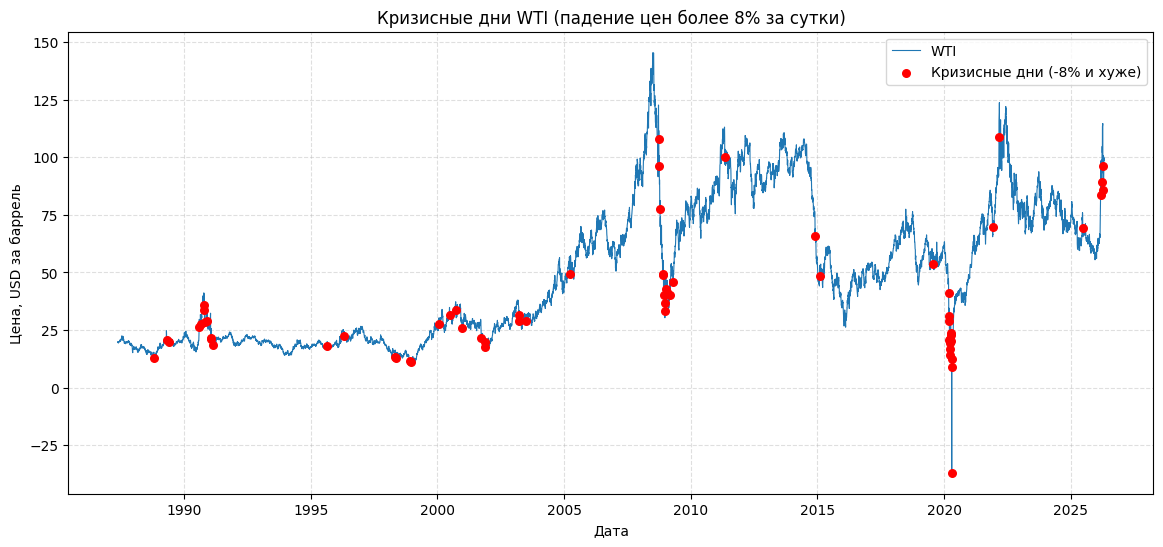

In [32]:
# 5.9.4 Отметить кризисные точки на графике

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["WTI"], label="WTI", linewidth=0.8)

# точки только там, где WTI_crisis == True
ax.scatter(df.index[df["WTI_crisis"]],
           df.loc[df["WTI_crisis"], "WTI"],
           color="red", s=30, label="Кризисные дни (-8% и хуже)", zorder=3)

ax.set_title("Кризисные дни WTI (падение цен более 8% за сутки)")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, USD за баррель")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

In [33]:
# 5.9.5 объяснить, почему такой критерий разумен для первичного анализа.


Порог -8% в день - это не «обычная волатильность», а действительно сильный удар по рынку: такие дни встречаются редко и обычно связаны с крупными новостями или общим стрессом на финансовых рынках. Если взять порог, скажем, -2%, кризисных дней станет слишком много и в выборку попадёт обычный рыночный шум. С текущим порогом мы выхватываем именно экстремальные события, которые хорошо видно и на графике цен: красные точки группируются в несколько периодов сильной нестабильности (например, вокруг больших кризисов и шоков на нефтяном рынке).

#### Дополнительно рекомендуется:

- сравнить кризисные дни WTI и Brent;
- посчитать накопленное падение через `drawdown`.

In [34]:
# 5.9.a Кризисные дни Brent и пересечение с WTI (порог -8%)

threshold = -0.08

df["WTI_crisis"] = df["WTI_ret"] < threshold
df["Brent_crisis"] = df["Brent_ret"] < threshold

wti_crisis_days = df[df["WTI_crisis"]]
brent_crisis_days = df[df["Brent_crisis"]]

print("Кризисных дней WTI:", len(wti_crisis_days))
print("Кризисных дней Brent:", len(brent_crisis_days))

# дни, когда одновременно плохо обоим
joint_crisis = df[df["WTI_crisis"] & df["Brent_crisis"]]
print("Совместных кризисных дней:", len(joint_crisis))

Кризисных дней WTI: 66
Кризисных дней Brent: 47
Совместных кризисных дней: 27


In [35]:
# Даты совместного кризиса

joint_crisis[["WTI", "WTI_ret", "Brent", "Brent_ret"]].head()

,WTI,WTI_ret,Brent,Brent_ret
Date,,,,
1988-10-24,12.94,-0.090014,12.20,-0.094955
1990-08-08,26.19,-0.115203,25.15,-0.080439
1990-08-27,27.36,-0.120257,27.65,-0.126382
1990-10-17,36.03,-0.084138,35.33,-0.092474
1990-10-22,28.46,-0.158486,27.45,-0.173193


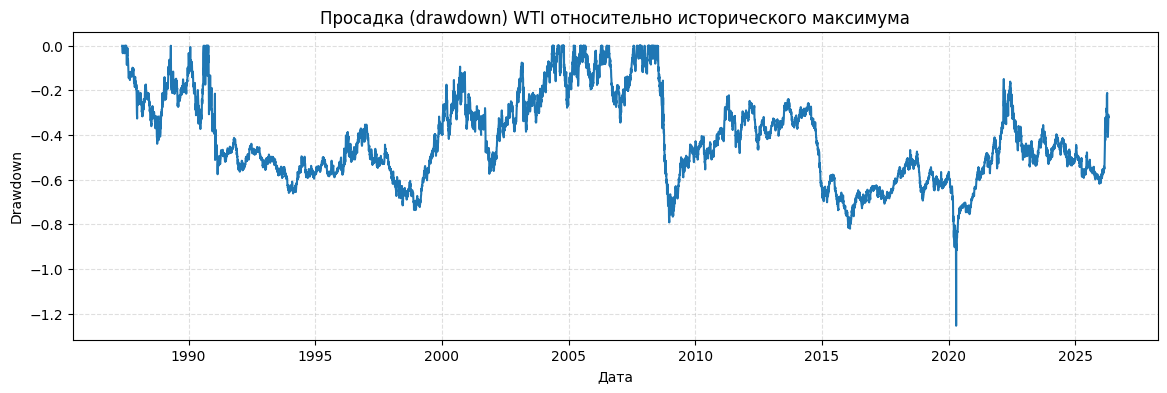

Максимальная просадка WTI: -1.2544903998348358


In [36]:
# 5.9.b Drawdown WTI (просадки)

# максимум цены, которого мы достигали к каждому дню
df["WTI_cummax"] = df["WTI"].cummax()

# текущая просадка: насколько ниже текущая цена своего исторического максимума
df["WTI_drawdown"] = df["WTI"] / df["WTI_cummax"] - 1

#График просадки
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["WTI_drawdown"])
ax.set_title("Просадка (drawdown) WTI относительно исторического максимума")
ax.set_xlabel("Дата")
ax.set_ylabel("Drawdown")
ax.grid(True, linestyle="--", alpha=0.4)
plt.show()

print("Максимальная просадка WTI:", df["WTI_drawdown"].min())

### 5.10. Поиск выбросов и аномальных значений

В обязательной части достаточно статистического подхода.

#### Требуется:

1. Найти грубые выбросы по предметному правилу.
   Например:
   - цена меньше 0;
   - цена слишком велика относительно типичного диапазона.

2. Найти статистические выбросы через **Z-score**.

In [37]:
# 5.10.1 Предметные выбросы

# предметные выбросы WTI
wti_negative = df[df["WTI"] < 0]
wti_high = df[df["WTI"] > 150] 

print("Отрицательные значения WTI:", len(wti_negative))
print("Очень высокие значения WTI:", len(wti_high))

wti_negative[["WTI"]].head()
wti_high[["WTI"]].head()

Отрицательные значения WTI: 1
Очень высокие значения WTI: 0


,WTI
Date,


Я проверил, тут нет нихрена, что и ожиалось. 1 эпизод в 2020-м году с отрицательными ценами - это историчкеский факи, а не аномалия, выкидывать его нельзя. А больше 150 нефть не подымается, потому что на цене 140 все перестают покупать пока цена не опустится. Хотя я знаю один европейский нефтеперерабатывающий завод, который покупал по 280 на той неделе, но это не на бирже. 

In [38]:
# 5.10.2 Статистические выбросы через Z‑score

df["WTI_z"] = (df["WTI"] - df["WTI"].mean()) / df["WTI"].std()

wti_outliers = df[df["WTI_z"].abs() > 3]
print("Статистических выбросов WTI (|z| > 3):", len(wti_outliers))

wti_outliers[["WTI", "WTI_z"]].head()

Статистических выбросов WTI (|z| > 3): 12


,WTI,WTI_z
Date,,
2008-06-06,138.51,3.036841
2008-06-26,138.91,3.050482
2008-06-27,139.69,3.077081
2008-06-30,139.96,3.086288
2008-07-01,141.06,3.123799


Z‑score — это способ взглянуть на те же данные глазами статистика: мы измеряем, насколько далеко каждая точка от среднего в единицах стандартного отклонения 
. Если |z| больше 3, точка сильно выпирает из общей массы и попадает в список статистических выбросов — это могут быть либо реальные экстремальные рыночные ситуации, либо ошибки в данных. В нашем случае в этот список попадают и известные кризисные эпизоды, и тот самый аномальный период с отрицательными ценами WTI в 2020 году, поэтому такие точки не стоит сразу «вычищать», лучше осознанно решить, как с ними обращаться 

### 5.11. Визуализация в Matplotlib

Это обязательный крупный блок.

Студент должен построить не менее **8 содержательных графиков**.

#### Минимальный обязательный набор

1. Линейный график WTI
2. Линейный график WTI и Brent на одной оси
3. WTI + скользящее среднее
4. Гистограмма распределения цен WTI
5. Boxplot цен WTI
6. График дневных доходностей WTI
7. График месячных средних
8. Scatter-график WTI vs Brent

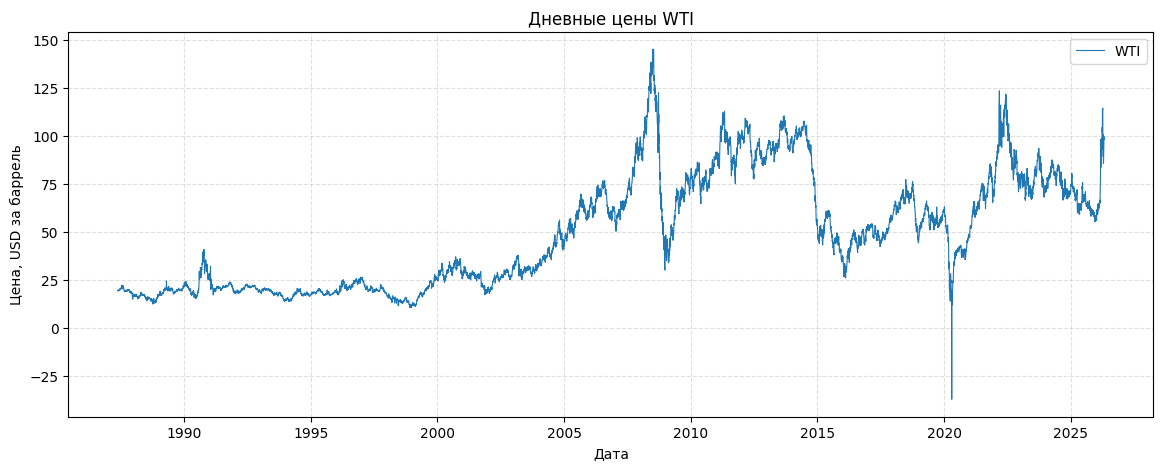

Этот график — просто «как жила цена WTI день за днём». Видно длинные спокойные отрезки с недорогой нефтью и несколько больших волн роста и падения, которые дальше будем разбирать уже более формально.


In [39]:
# 5.11.1 Линейный график WTI

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["WTI"], label="WTI", linewidth=0.8)

ax.set_title("Дневные цены WTI")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, USD за баррель")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.show()

print("Этот график — просто «как жила цена WTI день за днём». Видно длинные спокойные отрезки с недорогой нефтью и несколько больших волн роста и падения, которые дальше будем разбирать уже более формально.")

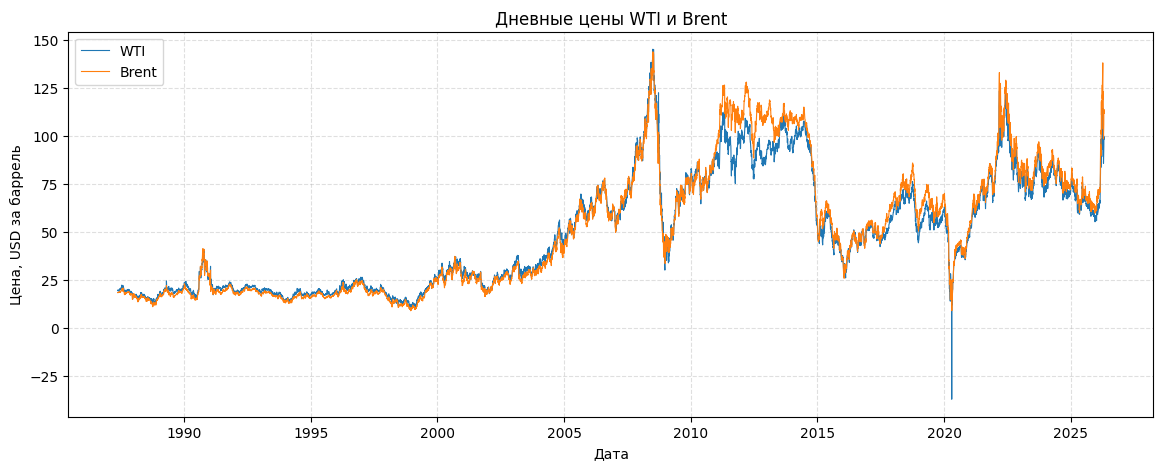

Здесь видно, что WTI и Brent почти всё время идут «рука об руку»: линии местами практически сливаются, а Brent обычно чуть выше WTI, что отражает его премию как международного эталона. Крупные пики и провалы у обоих совпадают по времени — это наглядная иллюстрация высокой корреляции, которую мы считали раньше.


In [40]:
# 5.11.2 Линейный график WTI и Brent вместе

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["WTI"], label="WTI", linewidth=0.8)
ax.plot(df.index, df["Brent"], label="Brent", linewidth=0.8)

ax.set_title("Дневные цены WTI и Brent")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, USD за баррель")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.show()

print("Здесь видно, что WTI и Brent почти всё время идут «рука об руку»: линии местами практически сливаются, а Brent обычно чуть выше WTI, что отражает его премию как международного эталона. Крупные пики и провалы у обоих совпадают по времени — это наглядная иллюстрация высокой корреляции, которую мы считали раньше.")

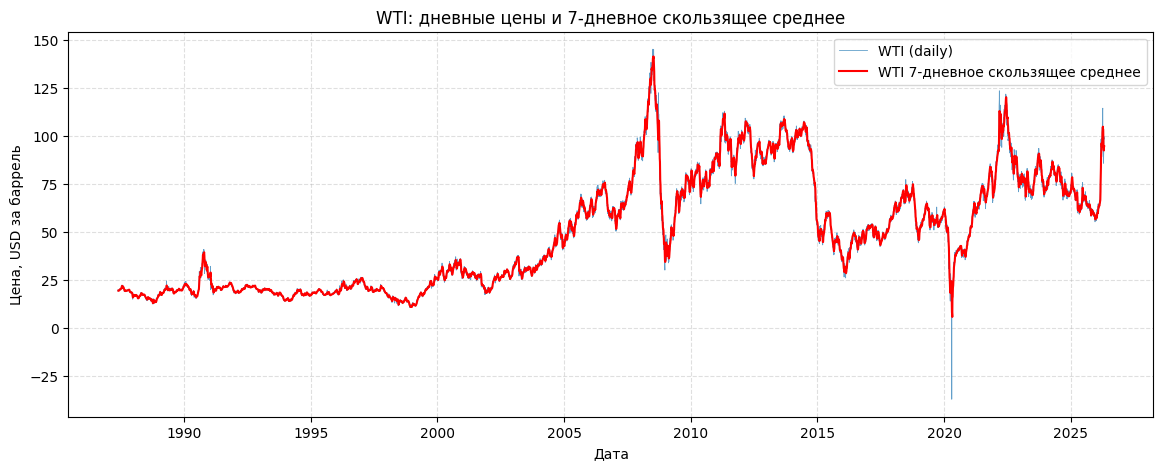

Красная линия — это сглаженная версия WTI: среднее за последние 7 дней. Она помогает увидеть «форму» движения без ежедневного шума и понять, где цена реально трендово растёт или падает, а где просто болтается вокруг горизонтали.


In [41]:
# 5.11.3 Линейный график WTI + скользящее среднее

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["WTI"], label="WTI (daily)", linewidth=0.6, alpha=0.7)
ax.plot(df.index, df["WTI_rolling_mean_7"], 
        label="WTI 7-дневное скользящее среднее", linewidth=1.5, color="red")

ax.set_title("WTI: дневные цены и 7-дневное скользящее среднее")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, USD за баррель")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.show()

print("Красная линия — это сглаженная версия WTI: среднее за последние 7 дней. Она помогает увидеть «форму» движения без ежедневного шума и понять, где цена реально трендово растёт или падает, а где просто болтается вокруг горизонтали.")

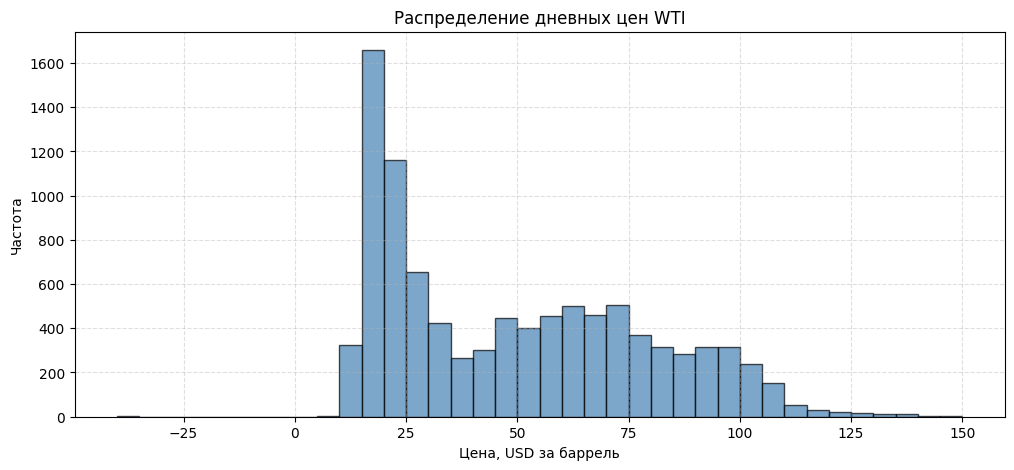

Гистограмма показывает, в каких ценовых диапазонах WTI проводил больше всего времени. Высокие столбики в районе основных уровней — это «обычная жизнь» рынка, а редкие столбики в хвостах отражают экстремальные периоды с очень низкими или очень высокими ценами


In [42]:
# 5.11.4 Гистограмма распределения цен WTI

bins = range(-40, 155, 5)  # шаг 5 USD, можно подогнать под свой диапазон

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df["WTI"].dropna(), bins=bins, alpha=0.7, color="steelblue", edgecolor="black")

ax.set_title("Распределение дневных цен WTI")
ax.set_xlabel("Цена, USD за баррель")
ax.set_ylabel("Частота")
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

print("Гистограмма показывает, в каких ценовых диапазонах WTI проводил больше всего времени. Высокие столбики в районе основных уровней — это «обычная жизнь» рынка, а редкие столбики в хвостах отражают экстремальные периоды с очень низкими или очень высокими ценами")

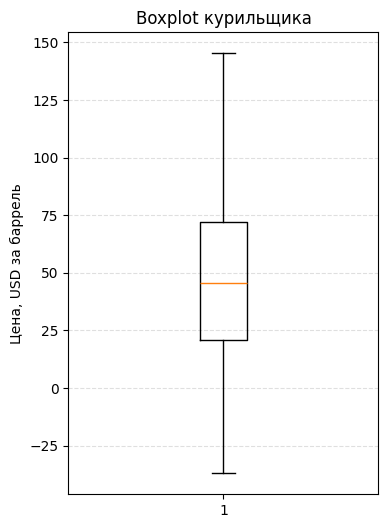

Boxplot компактно показывает медиану, основной диапазон цен и потенциальные выбросы. Тело ящика — это типичный диапазон, усики — более редкие значения, а отдельные точки могут соответствовать экстремальным периодам вроде кризисов.


In [43]:
# 5.11.5 Boxplot цен WTI

fig, ax = plt.subplots(figsize=(4, 6))

ax.boxplot(df["WTI"].dropna(), vert=True)
ax.set_title("Boxplot курильщика")
ax.set_ylabel("Цена, USD за баррель")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.show()

print("Boxplot компактно показывает медиану, основной диапазон цен и потенциальные выбросы. Тело ящика — это типичный диапазон, усики — более редкие значения, а отдельные точки могут соответствовать экстремальным периодам вроде кризисов.")

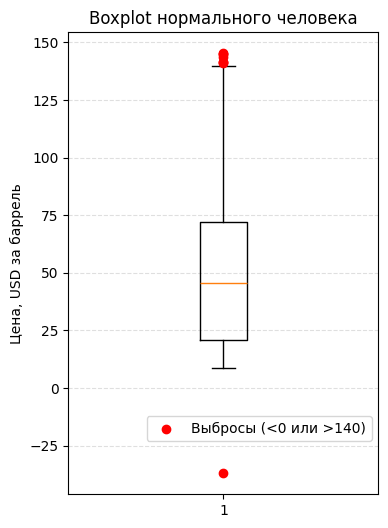

In [44]:
# 5.11.5 Boxplot WTI: усы в 10–140, выбросы отдельно

wti_vals = df["WTI"].dropna()

normal_mask = (wti_vals >= 0) & (wti_vals <= 140)
normal_vals = wti_vals[normal_mask]          # для ящика
outliers = wti_vals[~normal_mask]            # то, что <10 или >140

fig, ax = plt.subplots(figsize=(4, 6))

# boxplot только по нормальному диапазону
ax.boxplot(normal_vals, vert=True)

# выбросы поверх
ax.scatter([1] * len(outliers), outliers, color="red", zorder=3, label="Выбросы (<0 или >140)")

ax.set_title("Boxplot нормального человека")
ax.set_ylabel("Цена, USD за баррель")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="lower right", bbox_to_anchor=(1, 0.1))

plt.show()

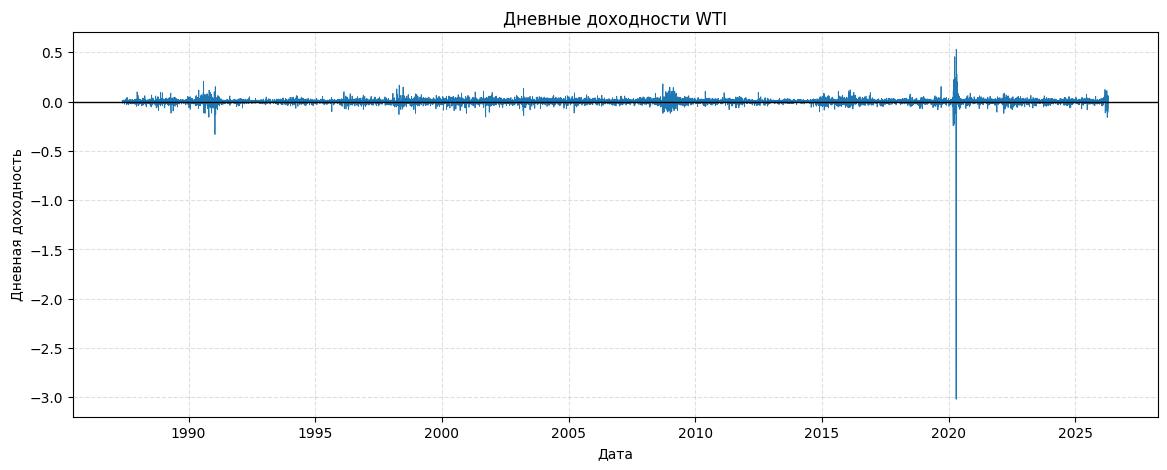

График дневных доходностей показывает, насколько сильно цена меняется от дня к дню в относительных единицах. Спокойные периоды выглядят как плотный шум вокруг нуля, а кризисы — как редкие, но крупные всплески вверх или вниз.


In [45]:
# 5.11.6 График дневных доходностей WTI

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["WTI_ret"], linewidth=0.6)
ax.set_title("Дневные доходности WTI")
ax.set_xlabel("Дата")
ax.set_ylabel("Дневная доходность")
ax.axhline(0, color="black", linewidth=1)
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

print("График дневных доходностей показывает, насколько сильно цена меняется от дня к дню в относительных единицах. Спокойные периоды выглядят как плотный шум вокруг нуля, а кризисы — как редкие, но крупные всплески вверх или вниз.")

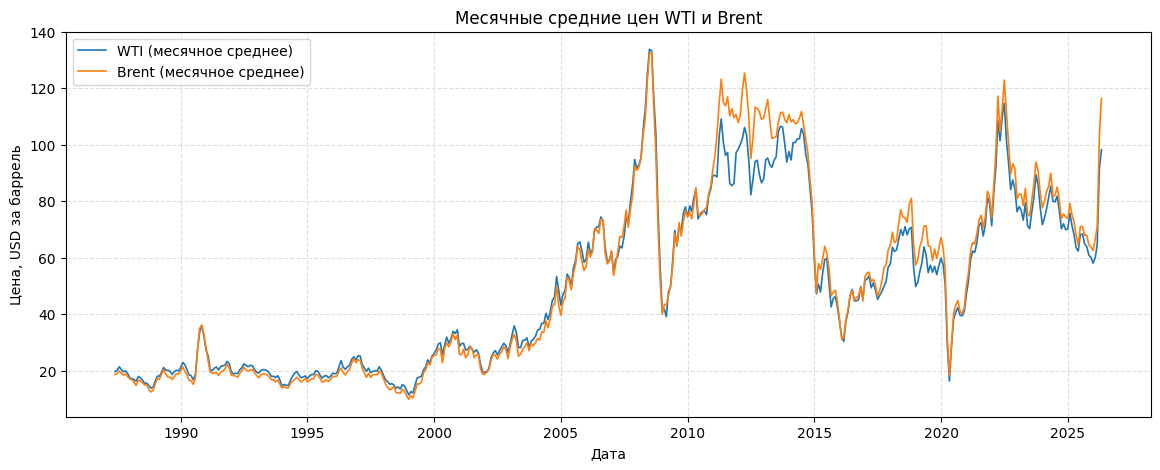

Месячные средние сглаживают дневной шум и показывают крупные волны рынка: когда нефть долго дешёвая, когда несколько лет держится на высоких уровнях и в какие периоды происходят затяжные падения.


In [46]:
# 5.11.7 График месячных средних цен WTI и Brent

monthly = df[["WTI", "Brent"]].resample("ME").mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly.index, monthly["WTI"], label="WTI (месячное среднее)", linewidth=1.2)
ax.plot(monthly.index, monthly["Brent"], label="Brent (месячное среднее)", linewidth=1.2)

ax.set_title("Месячные средние цен WTI и Brent")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, USD за баррель")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.show()

print("Месячные средние сглаживают дневной шум и показывают крупные волны рынка: когда нефть долго дешёвая, когда несколько лет держится на высоких уровнях и в какие периоды происходят затяжные падения.")

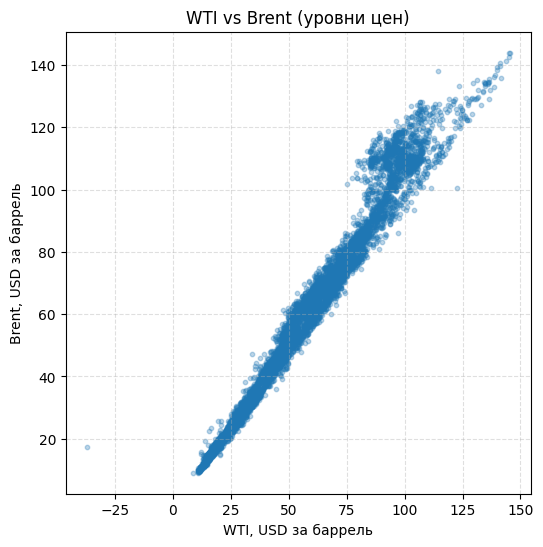

На scatter-графике каждая точка — это пара цен WTI и Brent за один день. Облако точек вытянуто вдоль почти прямой линии, что наглядно подтверждает сильную линейную связь между эталонами: когда один дорогой, второй почти всегда тоже дорогой.


In [47]:
# 5.11.8 Scatter-график WTI vs Brent

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(df["WTI"], df["Brent"], alpha=0.3, s=10)

ax.set_title("WTI vs Brent (уровни цен)")
ax.set_xlabel("WTI, USD за баррель")
ax.set_ylabel("Brent, USD за баррель")
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

print("На scatter-графике каждая точка — это пара цен WTI и Brent за один день. Облако точек вытянуто вдоль почти прямой линии, что наглядно подтверждает сильную линейную связь между эталонами: когда один дорогой, второй почти всегда тоже дорогой.")

#### Рекомендуемые дополнительные графики

9. Волатильность 30 дней  
10. Drawdown  
11. Локальный тренд `WTI_trend_30`  
12. График кризисных точек на фоне исходного ряда

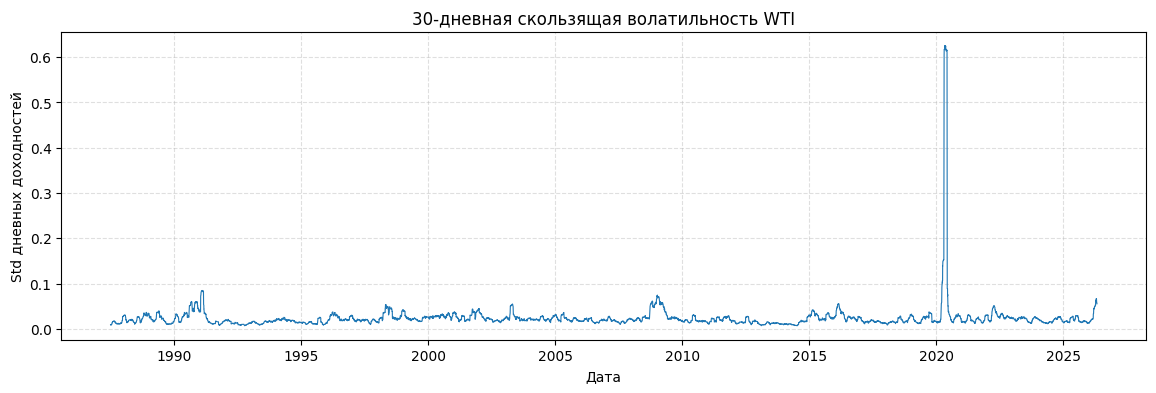

Здесь видно, насколько 'нервным' был рынок в разные периоды: в спокойные годы волатильность держится низко, а в кризисы она выстреливает, показывая, что дневные движения становятся намного резче.


In [48]:
# 5.11.9 Скользящая волатильность 30 дней (WTI)

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["WTI_volatility_30"], linewidth=0.8)
ax.set_title("30-дневная скользящая волатильность WTI")
ax.set_xlabel("Дата")
ax.set_ylabel("Std дневных доходностей")
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

print("Здесь видно, насколько 'нервным' был рынок в разные периоды: в спокойные годы волатильность держится низко, а в кризисы она выстреливает, показывая, что дневные движения становятся намного резче.")

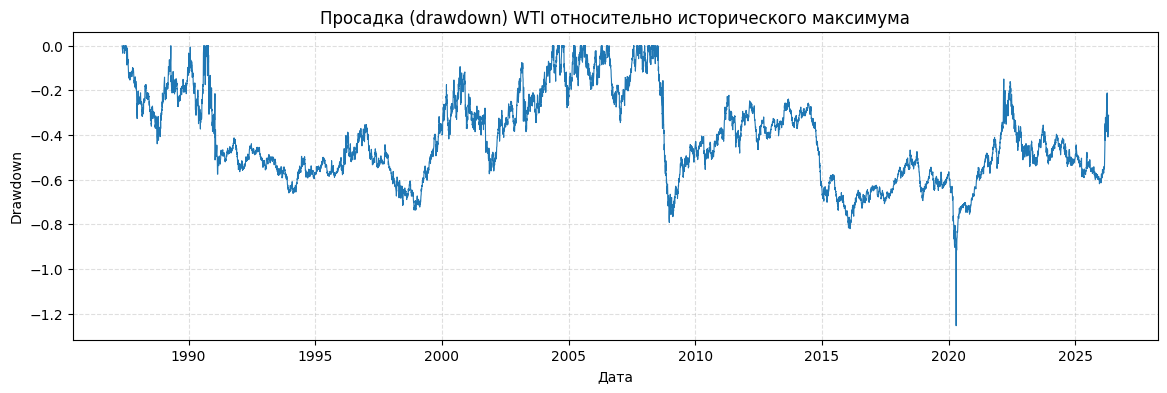

График drawdown показывает, насколько сильно и надолго цена отходила вниз от своих максимумов. Глубокие ямы — это не просто один плохой день, а длинные периоды, когда рынок так и не смог отыграть падение.


In [49]:
# 5.11.10 Drawdown WTI

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["WTI_drawdown"], linewidth=0.8)
ax.set_title("Просадка (drawdown) WTI относительно исторического максимума")
ax.set_xlabel("Дата")
ax.set_ylabel("Drawdown")
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

print("График drawdown показывает, насколько сильно и надолго цена отходила вниз от своих максимумов. Глубокие ямы — это не просто один плохой день, а длинные периоды, когда рынок так и не смог отыграть падение.")

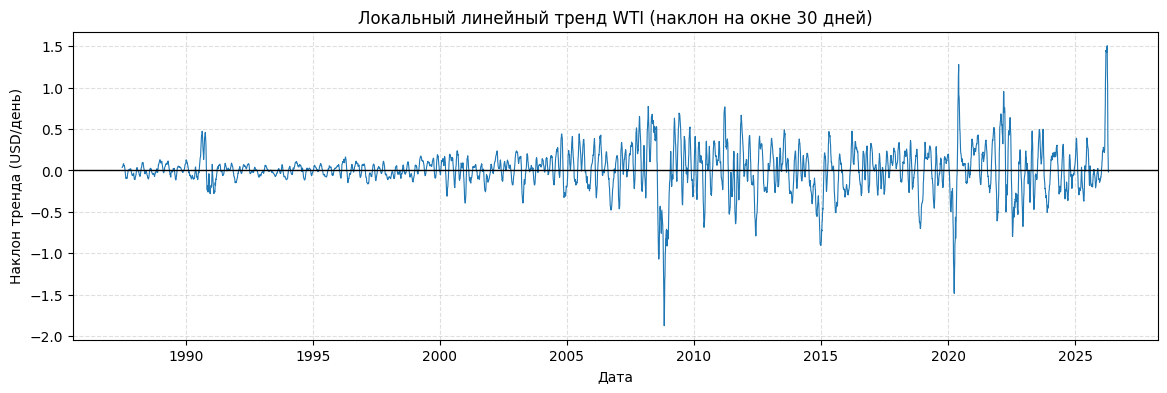

Этот график показывает, в какую сторону локально смотрит рынок: когда тренд выше нуля — на окне 30 дней цены в среднем ползут вверх, когда ниже — ползут вниз, а значения около нуля означают примерно боковое движение без выраженного тренда.


In [50]:
# 5.11.11 Локальный тренд WTI_trend_30

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["WTI_trend_30"], linewidth=0.8)
ax.set_title("Локальный линейный тренд WTI (наклон на окне 30 дней)")
ax.set_xlabel("Дата")
ax.set_ylabel("Наклон тренда (USD/день)")
ax.axhline(0, color="black", linewidth=1)
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

print("Этот график показывает, в какую сторону локально смотрит рынок: когда тренд выше нуля — на окне 30 дней цены в среднем ползут вверх, когда ниже — ползут вниз, а значения около нуля означают примерно боковое движение без выраженного тренда.")

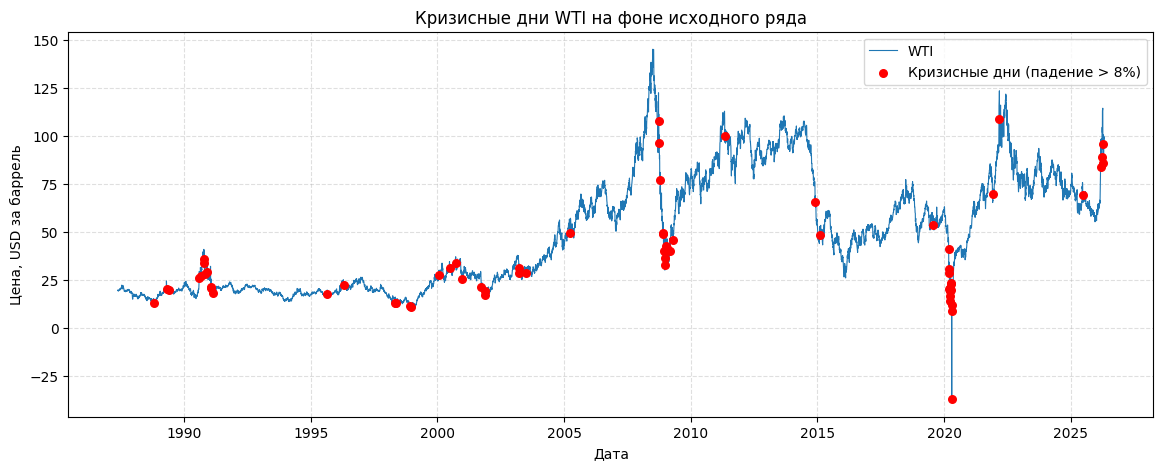

Красные точки отмечают дни, когда цена падала более чем на 8% за сутки. На графике видно, что такие экстремальные события собираются в несколько кластеров и совпадают с крупными кризисами на рынке нефти, а не раскиданы случайно по всему периоду.


In [51]:
# 5.11.12 Кризисные точки на фоне исходного ряда WTI

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["WTI"], label="WTI", linewidth=0.8)

ax.scatter(df.index[df["WTI_crisis"]],
           df.loc[df["WTI_crisis"], "WTI"],
           color="red", s=30, label="Кризисные дни (падение > 8%)", zorder=3)

ax.set_title("Кризисные дни WTI на фоне исходного ряда")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, USD за баррель")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.show()

print("Красные точки отмечают дни, когда цена падала более чем на 8% за сутки. На графике видно, что такие экстремальные события собираются в несколько кластеров и совпадают с крупными кризисами на рынке нефти, а не раскиданы случайно по всему периоду.")

### 5.12. Итоговая аналитическая интерпретация

В конце notebook студент обязан сделать письменные выводы.

#### Нужно ответить как минимум на вопросы:

1. Как ведут себя цены WTI и Brent в долгом периоде?
2. Видны ли периоды резкой нестабильности?
3. Насколько ряды похожи между собой?
4. Где наблюдаются кризисные дни?
5. Что показывает волатильность?
6. Можно ли считать ряд стационарным на бытовом уровне наблюдения?
7. Какие ограничения есть у проведённого анализа?

#### 5.12.1 Как ведут себя цены WTI и Brent в долгом периоде?
В долгом горизонте цены WTI и Brent проходят несколько заметных фаз: сначала длительный период относительно дешёвой и достаточно спокойной нефти, затем быстрый рост и пики 2000‑х годов, дальше плато на высоких уровнях и, наконец, череда глубоких просадок и более рваного поведения в последние годы. На графике месячных средних оба ряда ведут себя почти одинаково: крупные подъёмы и падения приходятся на одни и те же промежутки времени, а Brent почти всегда чуть выше WTI, что отражает его устойчивую премию как глобального эталона по сравнению с американским.

#### 5.12.2 Видны ли периоды резкой нестабильности?
Резкие периоды нестабильности хорошо выделяются по комбинации графиков: дневные доходности начинают выдавать большие по модулю значения, 30‑дневная волатильность резко подпрыгивает, а drawdown проваливается в глубокие отрицательные значения. Такие кластеры повышенной «трясучки» приходятся на крупные кризисы и шоковые события, включая мировой финансовый кризис 2008–2009 годов, падение цен в 2014–2016 годах и исторический эпизод с отрицательными ценами WTI в 2020 году.


#### 5.12.3 Насколько ряды похожи и движутся ли синхронно?
По уровню цен WTI и Brent очень похожи: линии на общих графиках практически накладываются, а корреляция уровней близка к единице, то есть оба эталона живут в одном «ценовом мире» и реагируют на одни и те же фундаментальные факторы. Корреляция дневных доходностей тоже положительная и довольно высокая, поэтому большинство резких движений (росты и падения) происходят синхронно, хотя в отдельные дни один сорт может реагировать чуть сильнее другого, что видно по небольшим расхождениям и временами расширяющемуся спреду WTI–Brent.

#### 5.12.4 Где наблюдаются кризисные дни?
Кризисные дни по критерию «падение больше 8% за сутки» - это редкие, но очень яркие точки, которые на графике цен выделяются как красные маркеры, сгруппированные вокруг нескольких ключевых периодов. Чаще всего такие дни возникают во время крупных рыночных стрессов и структурных шоков (2008–2009, 2014–2016, весна 2020 года), причём для значительной части этих дат одновременно выполняется критерий кризиса и для WTI, и для Brent, что подтверждает системный характер этих событий, а не локальные проблемы одного конкретного рынка.

#### 5.12.5 Что показывает волатильность?
Скользящая 30‑дневная волатильность дневных доходностей хорошо показывает, «насколько нервным» был рынок в разные периоды: в спокойные годы показатели держатся на относительно низком уровне, а в кризисах волатильность резко возрастает, показывая, что обычный дневной ход цены стал в разы больше. Видно, что всплески волатильности совпадают по времени с крупными макро‑ и геополитическими событиями, а после них рынок не сразу возвращается к «нормальному» режиму, то есть повышенная нестабильность может тянуться месяцами.


#### 5.12.6 Можно ли считать ряд стационарным на бытовом уровне?
На бытовом уровне ряд цен явно нельзя назвать стационарным: средний уровень цен и дисперсия заметно меняются во времени, что видно по смене «режимов» - от дешёвой нефти к длительным фазам высоких цен и обратно. Если же смотреть на дневные доходности, они выглядят гораздо ближе к стационарному шуму вокруг нуля, хотя и здесь проявляются периоды кластеризации волатильности, когда разброс значений доходности заметно выше обычного, а значит строгую стационарность для них тоже нельзя принимать без оговорок.


#### 5.12.7 Какие ограничения есть у проведённого анализа?
Проведённый анализ остаётся описательным и однофакторным: мы смотрим только на исторические цены и их простые функции, не включая в модель макроэкономические факторы, валютный курс, состояние спроса и предложения или структуру фьючерсного рынка. Кроме того, используются в основном линейные характеристики (корреляции, скользящие средние, простые критерии кризисных дней), поэтому более сложные эффекты - нелинейности, смена режимов, асимметрия реакции на шоки и прогнозирование - остаются за рамками и требуют отдельных, более продвинутых методов временных рядов.